In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print("imports ok")

imports ok


In [2]:
SEED     = 42
CLASSES  = ['glioma', 'meningioma', 'notumor', 'pituitary']
BASE_DIR = "brain-tumor-mri-dataset"
IMG_SIZE = (256, 256)

random.seed(SEED)
np.random.seed(SEED)

X_train, y_train = [], []
X_test, y_test   = [], []

for cls in CLASSES:
    for split, X_list, y_list in [('Training', X_train, y_train),
                                   ('Testing', X_test, y_test)]:
        folder = os.path.join(BASE_DIR, split, cls)
        for f in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, IMG_SIZE)
            X_list.append(img)
            y_list.append(cls)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test  = np.array(X_test)
y_test  = np.array(y_test)

X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"train : {X_train_norm.shape[0]} images")
print(f"test  : {X_test_norm.shape[0]} images")

train : 5600 images
test  : 1600 images


In [3]:
# aplatissement
X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat  = X_test_norm.reshape(X_test_norm.shape[0], -1)

# scaling
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_test_sc  = scaler.transform(X_test_flat)

print(f"shape : {X_train_flat.shape}")
print("scaling ok")

shape : (5600, 65536)
scaling ok


In [4]:
# architecture : 3 couches cachées 512 -> 256 -> 128
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    max_iter=50,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

mlp.fit(X_train_sc, y_train_enc)

y_pred_mlp = mlp.predict(X_test_sc)
acc_mlp    = accuracy_score(y_test_enc, y_pred_mlp)
print(f"\naccuracy MLP : {acc_mlp:.4f}")

Iteration 1, loss = 2.84347923
Validation score: 0.644643
Iteration 2, loss = 0.99016576
Validation score: 0.841071
Iteration 3, loss = 0.36665895
Validation score: 0.878571
Iteration 4, loss = 0.23636338
Validation score: 0.882143
Iteration 5, loss = 0.24323790
Validation score: 0.882143
Iteration 6, loss = 0.15309776
Validation score: 0.894643
Iteration 7, loss = 0.19596466
Validation score: 0.898214
Iteration 8, loss = 0.22065838
Validation score: 0.905357
Iteration 9, loss = 0.10068173
Validation score: 0.908929
Iteration 10, loss = 0.04262467
Validation score: 0.919643
Iteration 11, loss = 0.08820402
Validation score: 0.905357
Iteration 12, loss = 0.07038871
Validation score: 0.903571
Iteration 13, loss = 0.05294686
Validation score: 0.908929
Iteration 14, loss = 0.06388097
Validation score: 0.894643
Iteration 15, loss = 0.07584365
Validation score: 0.907143
Iteration 16, loss = 0.03620372
Validation score: 0.907143
Iteration 17, loss = 0.02942241
Validation score: 0.896429
Iterat

En comparaison avec Reglog on est passé de 80% à 84% pour MLP

In [5]:
#rapport de classification
print(classification_report(y_test_enc, y_pred_mlp, target_names=le.classes_))

              precision    recall  f1-score   support

      glioma       0.85      0.68      0.75       400
  meningioma       0.74      0.83      0.78       400
     notumor       0.87      0.99      0.93       400
   pituitary       0.92      0.86      0.89       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



Petite amélioration mias le recall pour glioma à 68% est toujours élévé, il reste encore mal détecté

cas dangereux (confiant mais faux) : 214
cas incertains mais corrects : 16


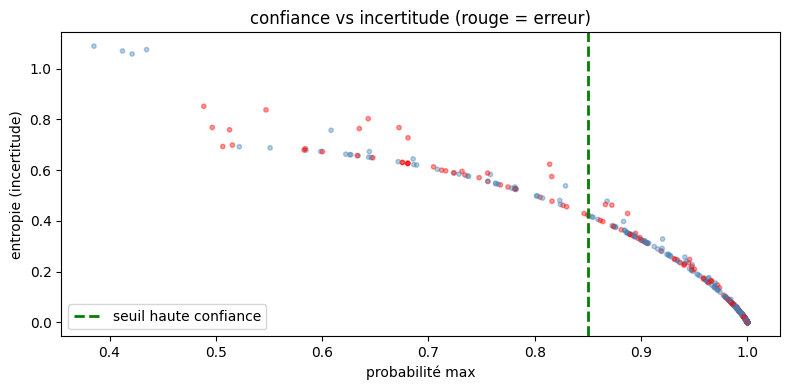

In [6]:
# probabilités du MLP
proba_mlp = mlp.predict_proba(X_test_sc)
max_prob  = proba_mlp.max(axis=1)

# entropie = mesure d'incertitude
entropie = -np.sum(proba_mlp * np.log(proba_mlp + 1e-10), axis=1)

# cas dangereux : confiant mais faux
confiant_faux = (max_prob > 0.85) & (y_pred_mlp != y_test_enc)
print(f"cas dangereux (confiant mais faux) : {confiant_faux.sum()}")

# cas incertains mais corrects
incertain_correct = (max_prob < 0.65) & (y_pred_mlp == y_test_enc)
print(f"cas incertains mais corrects : {incertain_correct.sum()}")

# visualisation
plt.figure(figsize=(8, 4))
plt.scatter(max_prob, entropie,
            c=['red' if e else 'steelblue' for e in (y_pred_mlp != y_test_enc)],
            alpha=0.4, s=10)
plt.axvline(0.85, color='green', ls='--', lw=2, label='seuil haute confiance')
plt.xlabel("probabilité max")
plt.ylabel("entropie (incertitude)")
plt.title("confiance vs incertitude (rouge = erreur)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Ici le modèle est confiant à 85% mais il y a 214 cas dangereux ce qui est énorme et dangereux pour un SAD.C'est ce qui montre la limitation du MLP, la calibration du CNN devrait réduire le nombre 